In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
def find_discrete_skewness(file_path):
    # data
    df = pd.read_csv(file_path, sep=';')
    df.columns = df.columns.str.strip()

    # discrete numeric features to analyze
    discrete_features = [
        'Application order', 
        'Age at enrollment', 
        'Curricular units 1st sem (credited)', 
        'Curricular units 1st sem (enrolled)',
        'Curricular units 1st sem (evaluations)', 
        'Curricular units 1st sem (approved)',
        'Curricular units 1st sem (without evaluations)',
        'Curricular units 2nd sem (credited)', 
        'Curricular units 2nd sem (enrolled)',
        'Curricular units 2nd sem (evaluations)', 
        'Curricular units 2nd sem (approved)',
        'Curricular units 2nd sem (without evaluations)'
    ]

    #subset dataframe
    subset_df = df[discrete_features]

    # calculate 
    mean = subset_df.mean()
    median = subset_df.median()
    std = subset_df.std()

    # pearson's median skewness formula: (3 * (mean - median)) / std
    pearson_median_skew = (3 * (mean - median)) / std

    # Format into a nice table
    skew_report = pearson_median_skew.sort_values(ascending=False).to_frame(name="Pearson's Median Skewness")
    
    print("--- Pearson's Median Skewness: Discrete Features ---")
    print(skew_report)

find_discrete_skewness('ProjectData.csv')

--- Pearson's Median Skewness: Discrete Features ---
                                                Pearson's Median Skewness
Application order                                                1.662015
Age at enrollment                                                1.290943
Curricular units 1st sem (credited)                              0.902337
Curricular units 2nd sem (credited)                              0.847231
Curricular units 2nd sem (without evaluations)                   0.598255
Curricular units 1st sem (without evaluations)                   0.597752
Curricular units 1st sem (enrolled)                              0.327278
Curricular units 2nd sem (enrolled)                              0.317142
Curricular units 1st sem (evaluations)                           0.214676
Curricular units 2nd sem (evaluations)                           0.048094
Curricular units 1st sem (approved)                             -0.284464
Curricular units 2nd sem (approved)                        

In [10]:
def find_discrete_outliers(file_path):
    # load names
    df = pd.read_csv(file_path, sep=';')
    df.columns = df.columns.str.strip()

    #discrete numeric features to analyze
    discrete_features = [
        'Application order', 
        'Age at enrollment', 
        'Curricular units 1st sem (credited)', 
        'Curricular units 1st sem (enrolled)',
        'Curricular units 1st sem (evaluations)', 
        'Curricular units 1st sem (approved)',
        'Curricular units 1st sem (without evaluations)',
        'Curricular units 2nd sem (credited)', 
        'Curricular units 2nd sem (enrolled)',
        'Curricular units 2nd sem (evaluations)', 
        'Curricular units 2nd sem (approved)',
        'Curricular units 2nd sem (without evaluations)'
    ]

    outlier_data = []

    for col in discrete_features:
        # Calculate IQR
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Define bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Count outliers
        outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        percentage = (outliers_count / len(df)) * 100
        
        outlier_data.append({
            'Feature': col, 
            'Outlier Count': outliers_count, 
            'Percentage (%)': round(percentage, 2)
        })

    #sort by outlier count
    outlier_summary = pd.DataFrame(outlier_data).sort_values(by='Outlier Count', ascending=False)
    
    print("--- Outlier Detection: Discrete Features ---")
    print(outlier_summary)

find_discrete_outliers('ProjectData.csv')

--- Outlier Detection: Discrete Features ---
                                           Feature  Outlier Count  \
2              Curricular units 1st sem (credited)            577   
0                                Application order            541   
7              Curricular units 2nd sem (credited)            530   
1                                Age at enrollment            441   
3              Curricular units 1st sem (enrolled)            424   
8              Curricular units 2nd sem (enrolled)            369   
6   Curricular units 1st sem (without evaluations)            294   
11  Curricular units 2nd sem (without evaluations)            282   
5              Curricular units 1st sem (approved)            180   
4           Curricular units 1st sem (evaluations)            158   
9           Curricular units 2nd sem (evaluations)            109   
10             Curricular units 2nd sem (approved)             44   

    Percentage (%)  
2            13.04  
0            12

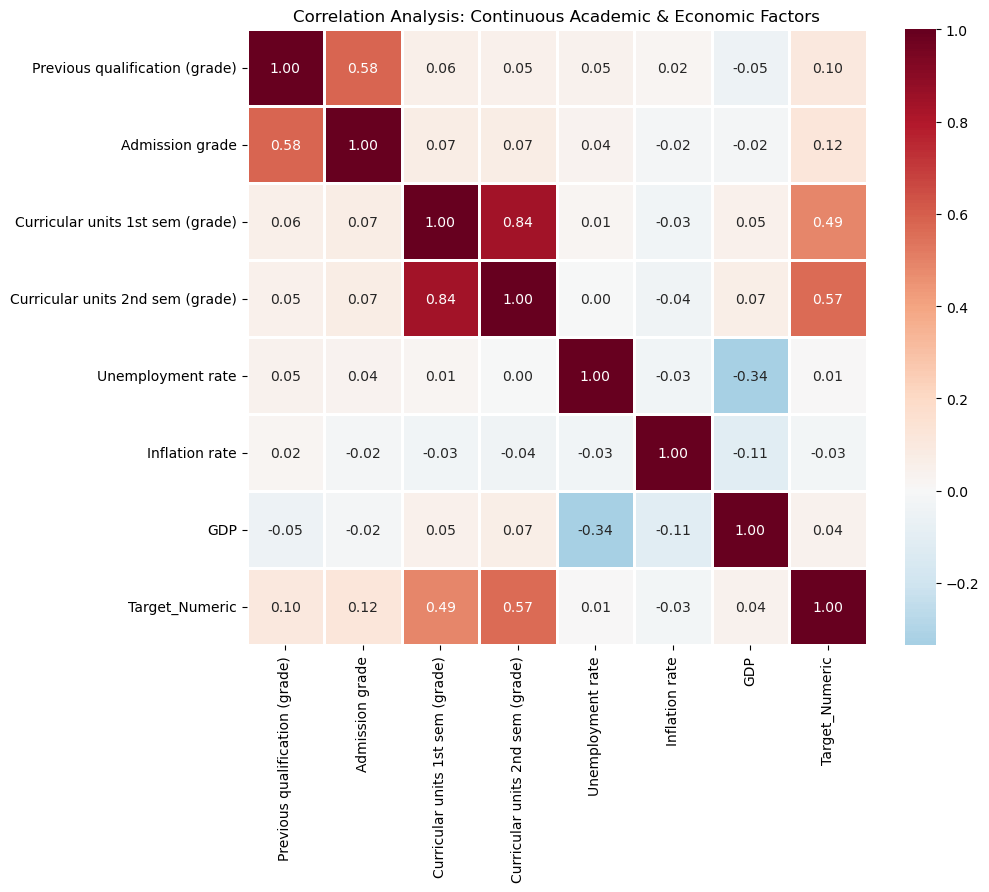

In [11]:

def correlation_analysis(file_path):    
    #load and clean
    df = pd.read_csv(file_path, sep=';')
    df.columns = df.columns.str.strip()

    #map target to numeric for correlation
    df['Target_Numeric'] = df['Target'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})

    #list of continuous features to analyze
    cont_cols = [
        'Previous qualification (grade)', 
        'Admission grade', 
        'Curricular units 1st sem (grade)', 
        'Curricular units 2nd sem (grade)',
        'Unemployment rate', 
        'Inflation rate', 
        'GDP',
        'Target_Numeric'
    ]

    #calcualte correlation
    cont_corr = df[cont_cols].corr()

    #plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(cont_corr, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=1)

    plt.title("Correlation Analysis: Continuous Academic & Economic Factors")
    plt.show()

correlation_analysis('ProjectData.csv')

In [12]:
def analyze_binary_features(file_path):
    #load and clean
    df = pd.read_csv(file_path, sep=';')
    df.columns = df.columns.str.strip()

    #list of binary features to analyze
    binary_features = [
        'Daytime/evening attendance', 'Displaced', 'Educational special needs', 
        'Debtor', 'Tuition fees up to date', 'Gender', 
        'Scholarship holder', 'International'
    ]

    binary_report = []

    for col in binary_features:
        # Calculate the balance (Percentage of '1's vs '0's)
        perc_ones = (df[col].sum() / len(df)) * 100
        
        #success rates for each group
        grad_rate_ones = len(df[(df[col] == 1) & (df['Target'] == 'Graduate')]) / len(df[df[col] == 1]) * 100
        grad_rate_zeros = len(df[(df[col] == 0) & (df['Target'] == 'Graduate')]) / len(df[df[col] == 0]) * 100
        
        binary_report.append({
            'Feature': col,
            'Presence (%)': f"{round(perc_ones, 1)}% (Yes)",
            'Grad Rate (If Yes)': f"{round(grad_rate_ones, 1)}%",
            'Grad Rate (If No)': f"{round(grad_rate_zeros, 1)}%",
            'Impact Diff': round(grad_rate_ones - grad_rate_zeros, 1)
        })
    #sort by impact difference
    report_df = pd.DataFrame(binary_report).sort_values(by='Impact Diff', ascending=False)
    
    print("--- Binary Feature Impact on Graduation ---")
    print(report_df.to_string(index=False))

analyze_binary_features('ProjectData.csv')

--- Binary Feature Impact on Graduation ---
                   Feature Presence (%) Grad Rate (If Yes) Grad Rate (If No)  Impact Diff
   Tuition fees up to date  88.1% (Yes)              56.0%              5.5%         50.5
        Scholarship holder  24.8% (Yes)              76.0%             41.3%         34.7
                 Displaced  54.8% (Yes)              54.6%             44.3%         10.3
Daytime/evening attendance  89.1% (Yes)              51.0%             41.6%          9.3
             International   2.5% (Yes)              49.1%             50.0%         -0.9
 Educational special needs   1.2% (Yes)              45.1%             50.0%         -4.9
                    Gender  35.2% (Yes)              35.2%             57.9%        -22.7
                    Debtor  11.4% (Yes)              20.1%             53.8%        -33.7


In [13]:
def analyze_categorical(file_path):
    df = pd.read_csv(file_path, sep=';')
    df.columns = df.columns.str.strip()

    # categorical features to analyze
    cat_features = ['Course', 'Mother\'s occupation', 'Father\'s occupation', 'Marital status']

    for col in cat_features:
        print(f"\n--- Analysis of {col} ---")
        
        # frequency of each category
        counts = df[col].value_counts().head(5)
        
        # succ
        risk_analysis = df.groupby(col)['Target'].value_counts(normalize=True).unstack().fillna(0)
        
        # Show Top 5 categories by student count and their Dropout %
        top_categories = counts.index
        summary = risk_analysis.loc[top_categories, ['Dropout', 'Graduate']]
        print(summary)

analyze_categorical('ProjectData.csv')


--- Analysis of Course ---
Target   Dropout  Graduate
Course                    
9500    0.154047  0.715405
9147    0.352632  0.363158
9238    0.183099  0.698592
9085    0.267062  0.510386
9773    0.305136  0.592145

--- Analysis of Mother's occupation ---
Target                Dropout  Graduate
Mother's occupation                    
9                    0.310717  0.521877
4                    0.303550  0.516524
5                    0.294340  0.528302
3                    0.270655  0.504274
2                    0.320755  0.433962

--- Analysis of Father's occupation ---
Target                Dropout  Graduate
Father's occupation                    
9                    0.319802  0.518812
7                    0.276276  0.557057
5                    0.286822  0.505814
4                    0.360104  0.448187
3                    0.296875  0.539062

--- Analysis of Marital status ---
Target           Dropout  Graduate
Marital status                    
1               0.302118  0.514162
